# Исследовательский анализ данных для центра реабилитации и исследования морских черепах «Тортилла». Разработка модели машинного обучения по предсказанию массы бесконтактным способом.

- Автор: Тайшин Илья
- Дата: 15/03/2026

### Цели 
Разработать модель линейной регрессии, которая на основе данных, получаемых от подсистемы компьютерного зрения TurtleCV (длина и ширина панциря, габариты головы, габариты ласт, количество колец на щитках панциря), позволяет предсказывать массу зелёной морской черепахи (Chelonia mydas).

Модель должна соответствовать следующим критериям качества и требованиям к продукту:

- **Точность:** Достичь значения метрики `R²` не ниже `0.97` на валидационной и тестовой выборках.

- **Абсолютная ошибка:** Обеспечить среднюю абсолютную ошибку `(MAE)` не более `5 кг` для взрослых особей `(массой 50–150 кг)`.

- **Относительная ошибка:** Оценить и минимизировать среднюю абсолютную ошибку в процентах (MAPE), так как модель должна работать для черепах разного возраста и размера.

- **Тип модели:** Использовать линейную модель для возможности интерпретации коэффициентов и создания простой функции прогнозирования.

- **Итоговый результат:** Написать функцию предсказания массы черепахи, использующую формулу линейной регрессии с полученными коэффициентами, для интеграции c прибором TurtleCV.

### Задачи проекта

1. Оформить название и краткое описание проекта.
2. Сформулировать задачу в терминах машинного обучения.
3. Импортировать все необходимые библиотеки.
4. Загрузить датасет.
5. Провести исследовательский анализ данных.
6. Предобработать данные и подготовьте их для машинного обучения.
7. Обучить несколько моделей.
8. Сравнить модели по метрикам на валидационной выборке.
9. Проверить лучшую модель на тестовой выборке.
10. Оценить важность признаков по итогам обучения лучшей модели.
11. Описать функцию для прогнозирования массы черепахи по заданным параметрам.
12. Написать общие выводы и рекомендации по дальнейшей работе модели.

### Описание данных
**Выгружаемый датафрейм содержит следующие данные:**

- `id` — идентификатор измерения.
- `binomial_name` — международное научное название вида черепахи.
- `registration_number` — регистрационный номер черепахи.
- `shell_length` — длина панциря, мм.
- `shell_width` — ширина панциря, мм.
- `head_length` — длина головы, мм.
- `head_width` — ширина головы, мм.
- `flipper_length_n` — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
- `flipper_width_n` — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
- `circle_count` — количество колец роста на панцире черепахи.
- `measure_count` — количество измерений, которые произвели, прежде чем усреднить показатели черепахи и добавить их в таблицу.
- `shell_crack` — наличие трещин панциря.
- `timestamp` — время внесения данных о черепахе.
- `weight` — масса черепахи, кг.


### Содержимое проекта

1. [Постановка задачи машинного обучения](#chapter-1)
2. [Подключение и настройка библиотек](#chapter-2)
3. [Загрузка датасета](#chapter-3)
4. [Исследовательский анализ данных](#chapter-4)
5. [Предобработка данных](#chapter-5) 
6. [Обучение моделей](#chapter-6)
7. [Сравнение моделей на валидационной выборке](#chapter-7)
8. [Проверка лучшей модели на тестовой выборке](#chapter-8)
9. [Оценка важности признаков](#chapter-9)
10. [Функция для прогнозирования веса черепахи](#chapter-10)
11. [Общие выводы и рекомендации по дальнейшей работе модели.](#chapter-11) 

## Постановка задачи машинного обучения <a name="chapter-1"></a>

В рамках данного проекта мы решаем задачу **регрессии**, поскольку необходимо предсказать непрерывное числовое значение — массу морской черепахи.

**Целевая переменная:**  
Масса черепахи (в килограммах). Это поле выбрано потому, что именно его требуется прогнозировать бесконтактным способом на основе габаритных измерений, получаемых от подсистемы компьютерного зрения TurtleCV.

**Метрики качества модели:**  
Для оценки точности и надежности прогнозов будут использоваться следующие метрики:

- `Средняя абсолютная ошибка (MAE)`: Показывает среднее отклонение предсказаний от фактических значений в килограммах.
$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$
где yi — фактическая масса, ŷi (y с крышкой) — предсказанная масса, n — количество наблюдений.

- `Средняя квадратичная ошибка (MSE)`: Усиливает влияние крупных ошибок, помогает выявить выбросы.
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- `Коэффициент детерминации (R²)`: Доля дисперсии целевой переменной, объяснённая моделью.
$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$
где \(\bar{y}\) — среднее фактических значений массы.

- `Средняя абсолютная ошибка в процентах (MAPE)`: Оценивает точность модели для черепах разного размера.
$$
\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$


**Критерии успешности проекта:**  
Проект считается успешным, если разработанная линейная модель удовлетворяет следующим пороговым значениям метрик:
- **R² ≥ 0.97** на валидационной и тестовой выборках — модель объясняет не менее `97%` изменчивости массы черепах.
- **MAE ≤ 5 кг** для взрослых особей (массой от 50 до 150 кг) — обеспечивает приемлемую точность при работе с основной целевой группой.
- Достижение минимально возможных значений **MAPE** и **MSE** для обеспечения надежности прогнозов в различных условиях.

## Подключение и настройка библиотек <a name="chapter-2"></a>

В блоке кода ниже, помимо уже указанных библиотек, импортируйте все остальные, которые планируете использовать для проекта.

In [1]:
# Обновляю pip чтобы не вызывать ошибки. Загружаю нужные для работы библиотеки.
!pip3 install -q --upgrade pip
!pip3 install -q seaborn pandas matplotlib
!pip3 install -q python-dotenv
!pip3 install -q phik

# Загружаю библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from phik import phik_matrix

# Загружаю библиотеки для построения модели
from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor 
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.dummy import DummyRegressor

    matplotlib-inline (<0.2.0appnope,>=0.1.0) ; platform_system == "Darwin"
                      ~~~~~~~~^
    matplotlib-inline (<0.2.0appnope,>=0.1.0) ; platform_system == "Darwin"
                      ~~~~~~~~^
    matplotlib-inline (<0.2.0appnope,>=0.1.0) ; platform_system == "Darwin"
                      ~~~~~~~~^
    matplotlib-inline (<0.2.0appnope,>=0.1.0) ; platform_system == "Darwin"
                      ~~~~~~~~^


## Загрузка датасета <a name="chapter-3"></a>

- Загрузите данные из файла `turtles.csv`, путь к файлу: `'/datasets/turtles.csv'`. При использовании метода [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) установите правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет — что нужно сделать, чтобы устранить препятствия?

**Общие сведенья о данных:**

In [2]:
# Загружаю данные из файла
df = pd.read_csv('/datasets/turtles.csv', sep='\t', decimal=',')

# Проверяю, что данные загрузились
print("Размер загруженных данных:", df.shape)
df.head()

Размер загруженных данных: (8861, 20)


,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


In [3]:
#Создаю копию датасета для возможности проверить внесенные изменения. 
temp = df.copy() 

In [4]:
#Вывожу кол-во пропусков в датафрейме
def show_missing_stats(tmp0, sort_by='Кол-во пропусков', ascending=False):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Сортировка
    missing_stats = missing_stats.sort_values(by=sort_by, ascending=ascending)
    
    # Форматирование и стилизация
    styled = missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm')
    return styled

show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
shell_crack,6685,0.7544
measure_count,264,0.0298
head_length,146,0.0165
head_width,146,0.0165
flipper_length_3,101,0.0114
flipper_width_3,101,0.0114
flipper_length_4,101,0.0114
flipper_width_4,101,0.0114
shell_length,87,0.0098
binomial_name,49,0.0055


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

In [6]:
#Изучаю единственный категориальный признак
df['binomial_name'].unique()

array(['Caretta caretta', 'Lepidochelys olivacea',
       'LEPIDOCHELYS OLIVACEA', 'Lepidochelys Olivacea',
       'lepidochelys olivacea', 'Chelonia mydas',
       'ERETMOCHELYS IMBRICATA', 'Eretmochelys imbricata',
       'Dermochelys coriacea', 'caretta caretta', 'CARETTA CARETTA',
       'chelonia mydas', 'Chelonia Mydas', 'CHELONIA MYDAS',
       'Dermochelys Coriacea', 'eretmochelys imbricata', nan,
       'Caretta Caretta', 'lepidochelys kempii', 'Lepidochelys kempii',
       'Eretmochelys Imbricata', 'dermochelys coriacea',
       'Lepidochelys Kempii', 'DERMOCHELYS CORIACEA'], dtype=object)

**Вывод по общим данным:** 
Датасет содержит `8861` записей и `20` признаков.
Типы данных соответствуют ожидаемым: 8 целочисленных, 10 вещественных и 2 объекта (строки).
Объём памяти небольшой — `1.4 МБ`, что позволяет работать без оптимизации, хотя при желании можно сократить вдвое.
Пропуски присутствуют, но их доля мала для большинства признаков (<3%):
- Целевая переменная weight пропущена всего в 0.2% случаев (19 строк).
- Основная проблема — признак shell_crack с 75% пропусков (6685 значений отсутствуют). Скорее всего, он не будет использоваться в модели.

Так как мы изучаем только 1 вид черепах, следовательно нам необходимо привести все названия к формату snake_case и отфильтровать датафрейм. 

**Подготовка основного датафрейма**

In [7]:
#Привожу данные к формату snake_case
def to_snake_case(value):
    return str(value).replace(' ', '_').lower()

df['binomial_name'] = df['binomial_name'].apply(to_snake_case)

In [8]:
df['binomial_name'].unique()

array(['caretta_caretta', 'lepidochelys_olivacea', 'chelonia_mydas',
       'eretmochelys_imbricata', 'dermochelys_coriacea', 'nan',
       'lepidochelys_kempii'], dtype=object)

In [9]:
#Фильтрую датафрейм по необходимому признаку, создавая его копию. Это будет основной датафрейм для работы. 
df_filtered = df[df['binomial_name'] == 'chelonia_mydas'].copy()

#Создаю копию датасета для возможности проверить внесенные изменения. 
temp1 = df_filtered.copy() 

In [10]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2829 entries, 8 to 8859
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2829 non-null   int64  
 1   binomial_name        2829 non-null   object 
 2   registration number  2825 non-null   object 
 3   shell_length         2794 non-null   float64
 4   shell_width          2829 non-null   int64  
 5   head_length          2790 non-null   float64
 6   head_width           2790 non-null   float64
 7   flipper_length_1     2829 non-null   int64  
 8   flipper_width_1      2829 non-null   int64  
 9   flipper_length_2     2829 non-null   int64  
 10  flipper_width_2      2829 non-null   int64  
 11  flipper_length_3     2798 non-null   float64
 12  flipper_width_3      2798 non-null   float64
 13  flipper_length_4     2798 non-null   float64
 14  flipper_width_4      2798 non-null   float64
 15  circle_count         2829 non-null   i

In [11]:
show_missing_stats(df_filtered)

,Кол-во пропусков,Доля пропусков
shell_crack,2152,0.7607
measure_count,81,0.0286
head_length,39,0.0138
head_width,39,0.0138
shell_length,35,0.0124
flipper_length_3,31,0.0110
flipper_width_3,31,0.0110
flipper_length_4,31,0.0110
flipper_width_4,31,0.0110
registration number,4,0.0014


**Вывод по основному датафрейму**
В датасете осталось `2829` записей (примерно треть исходного объёма), что достаточно для построения модели.
Пропуски распределены аналогично полному датасету:
- Целевая переменная weight пропущена всего в 3 строках (0.1%) — можно удалить.
- Признак shell_crack бесполезен: 76% пропусков (2152 из 2829) — колонку следует исключить.
- Остальные важные признаки (shell_length, head_length, flipper_length_* и др.) имеют 1–2% пропусков, что допустимо для удаления строк или заполнения.

Значимость остальных признаков для построения модели линейной регрессии оценим ниже.

Память занимает всего 464 КБ, оптимизация типов не обязательна, но возможна.

Данные готовы к дальнейшей предобработке — удалению строк с пропущенным weight, исключению shell_crack и обработке оставшихся пропусков.

In [12]:
# Анализирую возможность оптимизации типов данных
def check_memory_optimization(df, verbose=True):
    # Подготовка итогового отчета
    report = []
    
    # Текущий расход памяти 
    current_memory = df.memory_usage(deep=True).sum()
    
    for col in df.columns:
        col_data = df[col]
        col_type = col_data.dtype
        current_mem = col_data.memory_usage(deep=True)
        
        # Пропускаем, если колонка полностью пустая
        if col_data.isnull().all():
            suggested_type = col_type  # оставляю как есть
            new_mem = current_mem
            report.append({
                'Колонка': col,
                'Текущий тип': str(col_type),
                'Предлагаемый тип': 'unknown (все NaN)',
                'Текущая память (байт)': current_mem,
                'Память после (байт)': current_mem,
                'Экономия (байт)': 0
            })
            continue
        
        # Определяю предлагаемый тип
        suggested_type = col_type
        new_mem = current_mem
        
        # Для целочисленных колонок 
        if pd.api.types.is_integer_dtype(col_type):
            # Минимальное и максимальное значение (без учета NaN)
            min_val = col_data.min(skipna=True)
            max_val = col_data.max(skipna=True)
            
            # Проверяю, можно ли использовать беззнаковый тип (если все значения >=0)
            if min_val >= 0:
                # Беззнаковые целые
                if max_val <= np.iinfo(np.uint8).max:
                    suggested_type = 'uint8'
                elif max_val <= np.iinfo(np.uint16).max:
                    suggested_type = 'uint16'
                elif max_val <= np.iinfo(np.uint32).max:
                    suggested_type = 'uint32'
                else:
                    suggested_type = 'uint64'
            else:
                # Знаковые целые
                if min_val >= np.iinfo(np.int8).min and max_val <= np.iinfo(np.int8).max:
                    suggested_type = 'int8'
                elif min_val >= np.iinfo(np.int16).min and max_val <= np.iinfo(np.int16).max:
                    suggested_type = 'int16'
                elif min_val >= np.iinfo(np.int32).min and max_val <= np.iinfo(np.int32).max:
                    suggested_type = 'int32'
                else:
                    suggested_type = 'int64'
        
        # Для вещественных колонок 
        elif pd.api.types.is_float_dtype(col_type):
            # Проверяю возможность использования float32
            if col_type == 'float64':
                # проверяю, что значения не выходят за пределы f32
                min_val = col_data.min(skipna=True)
                max_val = col_data.max(skipna=True)
                if (min_val >= np.finfo(np.float32).min and 
                    max_val <= np.finfo(np.float32).max):
                    suggested_type = 'float32'
                else:
                    suggested_type = 'float64'
            else:
                suggested_type = col_type
        
        # Для object-колонок — проверка на категорию
        elif pd.api.types.is_object_dtype(col_type):
            # Если колонка строковая или смешанная, оцениваю целесообразность категории
            nunique = col_data.nunique(dropna=False)
            total = len(col_data)
            # Категориальный тип
            if nunique / total < 0.5:  # порог можно менять
                suggested_type = 'category'
            else:
                suggested_type = col_type
        
        # Для категориальных
        elif isinstance(col_type, pd.CategoricalDtype):
            suggested_type = col_type  # оставляем как есть
        
        # Для datetime 
        elif pd.api.types.is_datetime64_any_dtype(col_type):
            suggested_type = col_type
        
        # Прочие типы (например, timedelta)
        else:
            suggested_type = col_type
        
        # Если предлагаемый тип отличается от текущего, оцениваем новую память
        if suggested_type != col_type:
            try:
                # Для категории нужно создать временную категориальную колонку и измерить память
                if suggested_type == 'category':
                    temp_col = col_data.astype('category')
                else:
                    temp_col = col_data.astype(suggested_type)
                new_mem = temp_col.memory_usage(deep=True)
            except Exception as e:
                # Если преобразование невозможно, оставляем текущую память
                if verbose:
                    print(f"Колонка '{col}': не удалось преобразовать в {suggested_type} - {e}")
                suggested_type = col_type
                new_mem = current_mem
        else:
            new_mem = current_mem
        
        report.append({
            'Колонка': col,
            'Текущий тип': str(col_type),
            'Предлагаемый тип': str(suggested_type),
            'Текущая память (байт)': current_mem,
            'Память после (байт)': new_mem,
            'Экономия (байт)': current_mem - new_mem
        })
    
    report_df = pd.DataFrame(report)
    total_current = report_df['Текущая память (байт)'].sum()
    total_new = report_df['Память после (байт)'].sum()
    total_saved = total_current - total_new
    percent_saved = (total_saved / total_current * 100) if total_current > 0 else 0
    
    if verbose:
        print(f"Текущий расход памяти: {total_current:,.0f} байт ({total_current / 1024**2:.2f} МБ)")
        print(f"После оптимизации:     {total_new:,.0f} байт ({total_new / 1024**2:.2f} МБ)")
        print(f"Экономия:              {total_saved:,.0f} байт ({percent_saved:.1f}%)")
        print("\nДетали по колонкам:")
        display(report_df) 
    
    return report_df

report = check_memory_optimization(df_filtered)

Текущий расход памяти: 1,312,428 байт (1.25 МБ)
После оптимизации:     868,454 байт (0.83 МБ)
Экономия:              443,974 байт (33.8%)

Детали по колонкам:


,Колонка,Текущий тип,Предлагаемый тип,Текущая память (байт),Память после (байт),Экономия (байт)
0,id,int64,uint16,45264,28290,16974
1,binomial_name,object,category,223491,25640,197851
2,registration number,object,object,274185,274185,0
3,shell_length,float64,float32,45264,33948,11316
4,shell_width,int64,uint16,45264,28290,16974
5,head_length,float64,float32,45264,33948,11316
6,head_width,float64,float32,45264,33948,11316
7,flipper_length_1,int64,uint16,45264,28290,16974
8,flipper_width_1,int64,uint16,45264,28290,16974
9,flipper_length_2,int64,uint16,45264,28290,16974


**Итоговый вывод по загруженным данным**

1. **Загрузка данных**  
   Файл `/datasets/turtles.csv` успешно загружен с корректными параметрами: разделитель столбцов — табуляция (`sep='\t'`), разделитель дробной части — запятая (`decimal=','`). Данные соответствуют описанию: присутствуют все необходимые признаки (длина и ширина панциря, головы, ласт, количество колец и целевая переменная `weight`).

2. **Общие сведения о данных**  
   - Исходный датасет содержит **8861 запись** и **20 столбцов**.  
   - Типы данных соответствуют ожидаемым: 8 целочисленных, 10 вещественных, 2 строковых.  
   - Память: **1.4 МБ**, что позволяет работать без дополнительной оптимизации.  
   - Присутствуют пропуски, но их доля мала для большинства признаков (<3%), за исключением столбца `shell_crack` (75% пропусков). Целевая переменная `weight` пропущена всего в 19 строках (0.2%).

3. **Фильтрация по виду**  
   После приведения названий к формату snake_case и выделения только особей *Chelonia mydas* получен датасет из **2829 записей** — этого достаточно для построения модели линейной регрессии.

4. **Оценка возможности продолжения работы**  
   **Да, работа возможна** после выполнения обязательных шагов предобработки:  
   - удалить 3 строки с пропущенным `weight` (целевая переменная);  
   - исключить столбец `shell_crack` (более 76% пропусков);  
   - удалить служебные признаки (`id`, `binomial_name`, `registration number`, `timestamp`, `measure_count`), не несущие информации для прогноза массы;  
   - обработать оставшиеся пропуски в признаках (`shell_length`, `head_length`, `head_width`, `flipper_length_3/4`, `flipper_width_3/4`) – например, удалить соответствующие строки (потеря около 2% данных) или заполнить медианными значениями.  
   - Проверить явные и неявные дубликаты
   - (Опционально) выполнить оптимизацию типов данных, что позволит сократить память на 33% (с 1.25 МБ до 0.83 МБ).

После выполнения этих шагов данные будут полностью готовы к обучению модели.

## Исследовательский анализ данных <a name="chapter-4"></a>

Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

1) **Анализ данных о представленных черепаха**

In [13]:
df['binomial_name'].unique()

array(['caretta_caretta', 'lepidochelys_olivacea', 'chelonia_mydas',
       'eretmochelys_imbricata', 'dermochelys_coriacea', 'nan',
       'lepidochelys_kempii'], dtype=object)

1. В датасете представлены данные о 6 видах черепах. А также об 1 виде без названия:
   - caretta_caretta
   - lepidochelys_olivacea
   - chelonia_mydas
   - eretmochelys_imbricata
   - dermochelys_coriacea
   - epidochelys_kempii
   
   - nan (неизвестный вид)

In [14]:
species_abs = df['binomial_name'].value_counts()

# Подсчёт относительного количества (доля в процентах)
species_rel = df['binomial_name'].value_counts(normalize=True) * 100

# Создаю сводный дф
species_summary = pd.DataFrame({
    'Абсолютное количество': species_abs,
    'Доля (%)': species_rel.round(2)
})
species_summary

,Абсолютное количество,Доля (%)
lepidochelys_olivacea,4215,47.57
chelonia_mydas,2829,31.93
caretta_caretta,847,9.56
dermochelys_coriacea,484,5.46
eretmochelys_imbricata,409,4.62
nan,49,0.55
lepidochelys_kempii,28,0.32


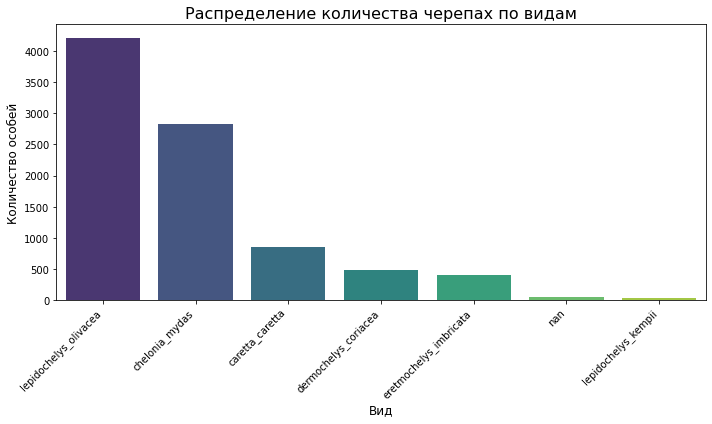

In [15]:
# Считаю кол-во особей каждого вида
species_counts = df['binomial_name'].value_counts()

# Строю столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(x=species_counts.index, y=species_counts.values, palette='viridis')
plt.title('Распределение количества черепах по видам', fontsize=16)
plt.xlabel('Вид', fontsize=12)
plt.ylabel('Количество особей', fontsize=12)
plt.xticks(rotation=45, ha='right')  # поворот подписей для читаемости
plt.tight_layout()
plt.show()

В датасете преобладают два вида: `Lepidochelys olivacea` — `4215` особей (47.6%) и `Chelonia mydas` — `2829` особей (31.9%). Вместе они составляют почти `80%` выборки.

Остальные виды представлены значительно меньше: `Caretta caretta` — `847` особей (9.6%), `Dermochelys coriacea` — `484` (5.5%), `Eretmochelys imbricata` — `409` (4.6%).

Присутствует неизвестный вид (49 записей, 0.55%) и крайне малое количество особей `Lepidochelys kempii` — всего `28` (0.32%).

**Вывод:** Для построения модели линейной регрессии для `Chelonia mydas` данных достаточно `2829` записей. Для других видов, особенно малочисленных, потребуется либо сбор дополнительных данных.


**Подготовка датафрейма к работе**

In [16]:
#Оптимизирую типы данных
def optimize_dataframe(df, categorical_threshold=0.5, verbose=True, inplace=False):
    if not inplace:
        df = df.copy()
    
    changes = []  # для отчёта
    
    for col in df.columns:
        col_data = df[col]
        old_type = col_data.dtype
        suggested_type = old_type
        
        # Пропускаю, если все значения НаН
        if col_data.isnull().all():
            continue
        
        # Определяю оптимальный тип 
        if pd.api.types.is_integer_dtype(old_type):
            min_val = col_data.min(skipna=True)
            max_val = col_data.max(skipna=True)
            
            if min_val >= 0:
                # Беззнаковые
                if max_val <= np.iinfo(np.uint8).max:
                    suggested_type = 'uint8'
                elif max_val <= np.iinfo(np.uint16).max:
                    suggested_type = 'uint16'
                elif max_val <= np.iinfo(np.uint32).max:
                    suggested_type = 'uint32'
                else:
                    suggested_type = 'uint64'
            else:
                # Знаковые
                if min_val >= np.iinfo(np.int8).min and max_val <= np.iinfo(np.int8).max:
                    suggested_type = 'int8'
                elif min_val >= np.iinfo(np.int16).min and max_val <= np.iinfo(np.int16).max:
                    suggested_type = 'int16'
                elif min_val >= np.iinfo(np.int32).min and max_val <= np.iinfo(np.int32).max:
                    suggested_type = 'int32'
                else:
                    suggested_type = 'int64'
        
        elif pd.api.types.is_float_dtype(old_type):
            if old_type == 'float64':
                min_val = col_data.min(skipna=True)
                max_val = col_data.max(skipna=True)
                if (min_val >= np.finfo(np.float32).min and 
                    max_val <= np.finfo(np.float32).max):
                    suggested_type = 'float32'
                else:
                    suggested_type = 'float64'
            else:
                suggested_type = old_type
        
        elif pd.api.types.is_object_dtype(old_type):
            nunique = col_data.nunique(dropna=False)
            total = len(col_data)
            if nunique / total < categorical_threshold:
                suggested_type = 'category'
            else:
                suggested_type = old_type
        
        # Прочие типы (category, datetime)
        
        # Применяю преобразование, если тип изменился
        if suggested_type != old_type:
            try:
                df[col] = col_data.astype(suggested_type)
                new_type = df[col].dtype
                changes.append({
                    'Колонка': col,
                    'Старый тип': str(old_type),
                    'Новый тип': str(new_type)
                })
            except Exception as e:
                if verbose:
                    print(f"Не удалось преобразовать колонку '{col}' в {suggested_type}: {e}")
    
    if verbose:
        if changes:
            print("Оптимизация завершена. Изменены следующие колонки:")
            print(pd.DataFrame(changes))
            # Покажем итоговую память
            mem_before = df.memory_usage(deep=True).sum()
            mem_after = df.memory_usage(deep=True).sum()  # уже после изменений
            print(f"Память после оптимизации: {mem_after:,.0f} байт ({mem_after / 1024**2:.2f} МБ)")
        else:
            print("Оптимизация не требуется — все типы уже оптимальны.")
    
    if not inplace:
        return df

In [17]:
df_opt = optimize_dataframe(df_filtered)

Оптимизация завершена. Изменены следующие колонки:
             Колонка Старый тип Новый тип
0                 id      int64    uint16
1      binomial_name     object  category
2       shell_length    float64   float32
3        shell_width      int64    uint16
4        head_length    float64   float32
5         head_width    float64   float32
6   flipper_length_1      int64    uint16
7    flipper_width_1      int64    uint16
8   flipper_length_2      int64    uint16
9    flipper_width_2      int64    uint16
10  flipper_length_3    float64   float32
11   flipper_width_3    float64   float32
12  flipper_length_4    float64   float32
13   flipper_width_4    float64   float32
14      circle_count      int64     uint8
15     measure_count    float64   float32
16       shell_crack    float64   float32
17         timestamp      int64    uint32
18            weight    float64   float32
Память после оптимизации: 438,446 байт (0.42 МБ)


**Чистка датафрейма от пропусков**

In [18]:
#Вывожу пропуски
show_missing_stats(df_opt)

,Кол-во пропусков,Доля пропусков
shell_crack,2152,0.7607
measure_count,81,0.0286
head_length,39,0.0138
head_width,39,0.0138
shell_length,35,0.0124
flipper_length_3,31,0.0110
flipper_width_3,31,0.0110
flipper_length_4,31,0.0110
flipper_width_4,31,0.0110
registration number,4,0.0014


Признаки которые не влияют на предсказание модели: 
- `id` — уникальный идентификатор записи, не несёт информации о физических характеристиках.
- `binomial_name` — после фильтрации остался только один вид (Chelonia mydas), столбец стал константным и бесполезен для модели.
- `registration number` — регистрационный номер, служебная информация, не влияет на массу.
- `measure_count` — количество измерений, не связано с габаритами черепахи.
- `shell_crack` — признак наличия трещины, имеет `76%` пропусков и не влияет на массу.
- `timestamp` — временная метка, не влияет на массу.

In [19]:
# Список колонок, которые не нужны для модели
cols_to_drop = [
    'id',
    'binomial_name',
    'registration number',
    'measure_count',
    'shell_crack',
    'timestamp'
]

# Удаляю колонки и сохраняю результат в новый дф
df_model = df_opt.drop(columns=cols_to_drop)

In [20]:
show_missing_stats(df_model)

,Кол-во пропусков,Доля пропусков
head_length,39,0.0138
head_width,39,0.0138
shell_length,35,0.0124
flipper_length_3,31,0.0110
flipper_width_3,31,0.0110
flipper_length_4,31,0.0110
flipper_width_4,31,0.0110
weight,3,0.0011


Доля пропусков незначительная можно удалить данные или заменить их на медиану или средние значения.
Так как целевая переменная `weight` содержит 3 пропуска, их лучше исключить из выборки для корректного обучения модели. 

Заполнение пропусков медианой буду производить после разделения датафрейма на выборки

**Обработка явных и неявных дубликатов**

In [21]:
# Удаляю строки с пропущенным значением целевой переменной
df_model = df_model.dropna(subset=['weight'])
print(f"После удаления пропусков в weight осталось строк: {len(df_model)}")

# Сохраняю текущий размер для отслеживания изменений
initial_len = len(df_model)
print(f"Размер датафрейма для проверки дубликатов: {initial_len} строк")

# Определяю колонки для поиска дубликатов – все, кроме целевой переменной weight
cols_for_dupes = [col for col in df_model.columns if col != 'weight']

# Поиск явных дубликатов (полное совпадение во всех признаках)
dupes = df_model.duplicated(subset=cols_for_dupes, keep=False)
print(f"Найдено явных дубликатов (полное совпадение признаков): {dupes.sum()}")

if dupes.sum() > 0:
    print("Примеры дубликатов (первые 5):")
    display(df_model[dupes].sort_values(by=cols_for_dupes[:2]).head(5))
    
    # Удаляю дубликаты, оставляя только первое вхождение каждой группы
    df_model = df_model.drop_duplicates(subset=cols_for_dupes, keep='first')
    print(f"После удаления дубликатов осталось строк: {len(df_model)}")
    print(f"Удалено: {initial_len - len(df_model)} строк ({(initial_len - len(df_model))/initial_len*100:.2f}%)")
else:
    print("Явных дубликатов не обнаружено.")

После удаления пропусков в weight осталось строк: 2826
Размер датафрейма для проверки дубликатов: 2826 строк
Найдено явных дубликатов (полное совпадение признаков): 680
Примеры дубликатов (первые 5):


,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
7579,683.0,661,96.0,133.0,459,379,422,380,322.0,329.0,364.0,319.0,80,50.981998
8598,683.0,661,96.0,133.0,459,379,422,380,322.0,329.0,364.0,319.0,80,50.981998
7704,685.0,661,95.0,102.0,403,338,442,395,351.0,342.0,346.0,285.0,70,50.291000
8723,685.0,661,95.0,102.0,403,338,442,395,351.0,342.0,346.0,285.0,70,50.291000
7655,686.0,616,112.0,123.0,396,435,431,358,321.0,291.0,280.0,322.0,66,49.230000


После удаления дубликатов осталось строк: 2486
Удалено: 340 строк (12.03%)


**Перед тем как перейти к заполнению медианой пропусков, необходимо проверить их распределение.**

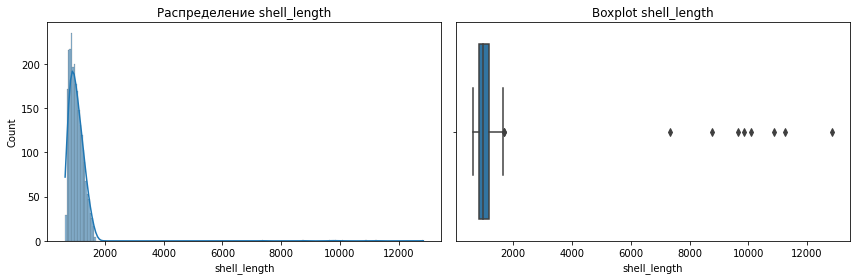

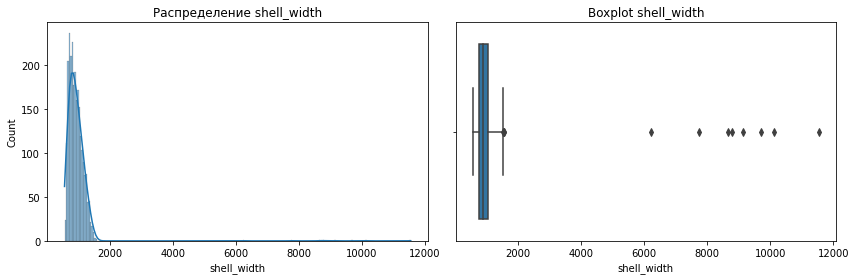

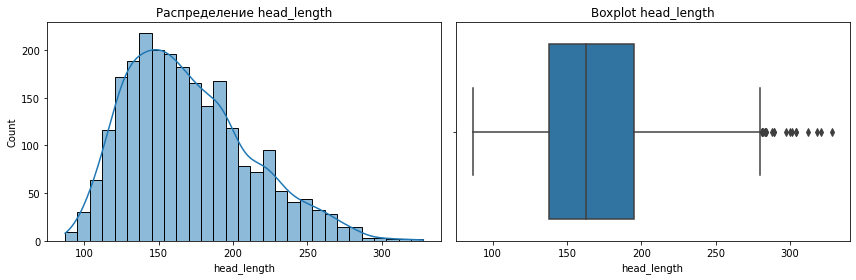

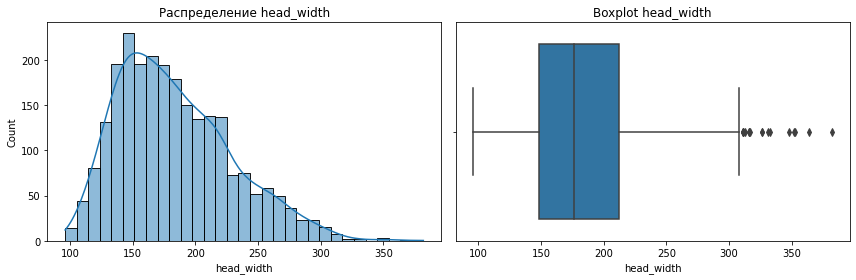

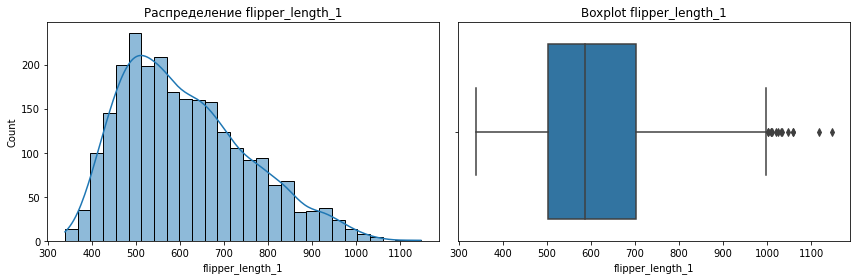

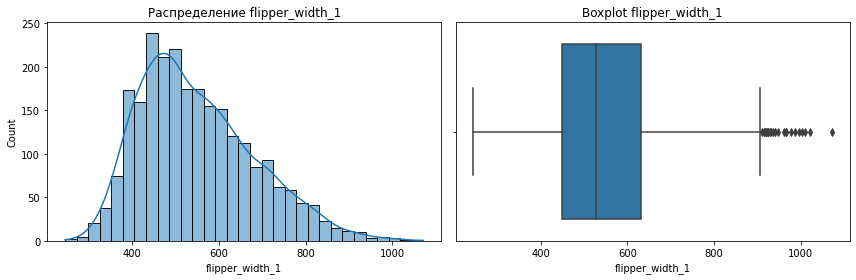

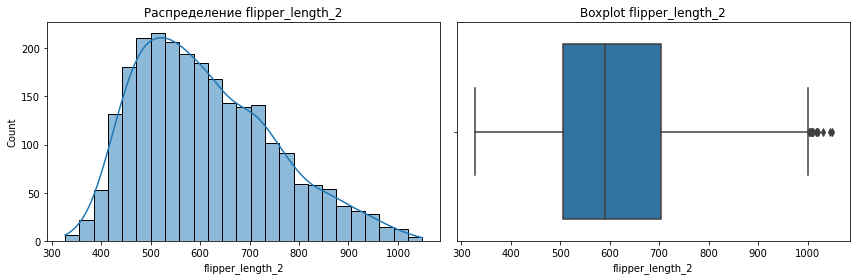

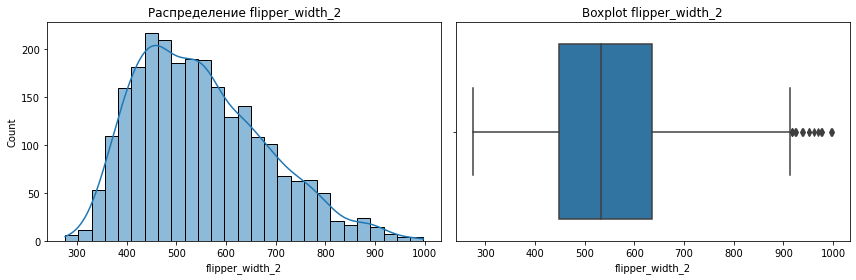

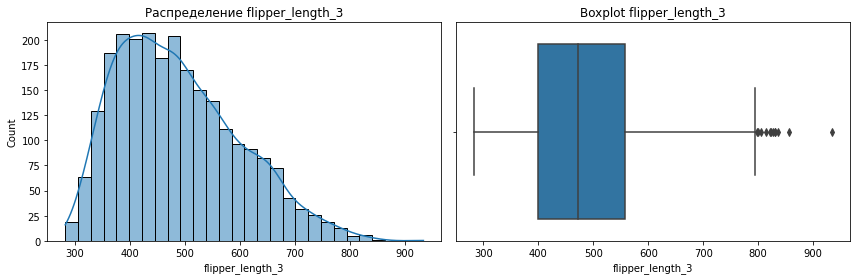

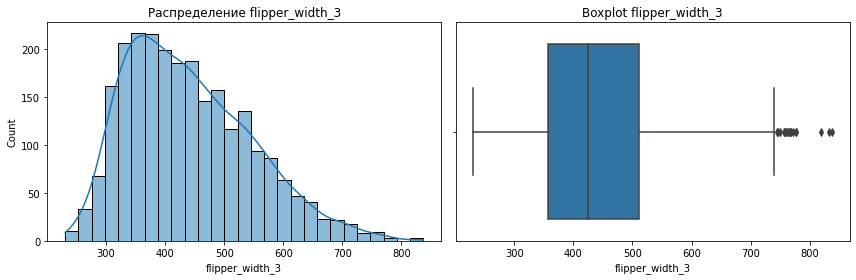

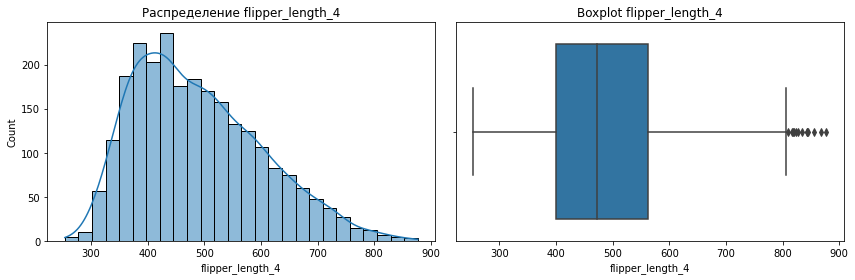

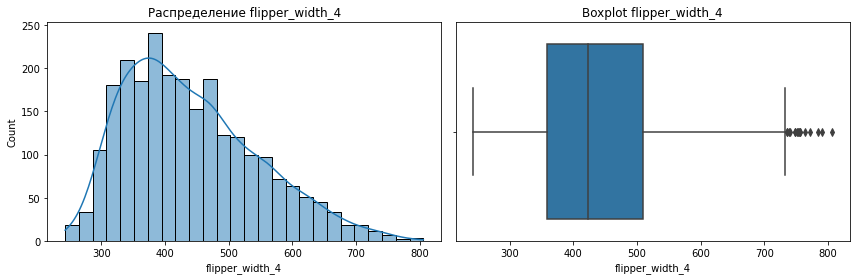

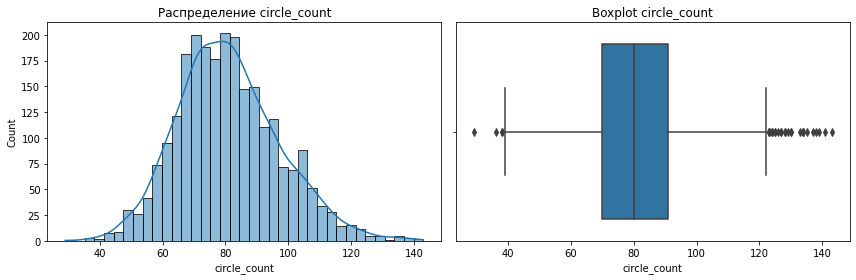

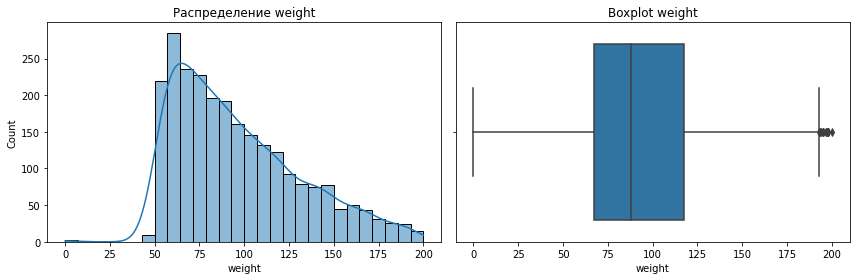

In [22]:
# Список признаков модели без целевой переменной
all_cols = [
    'shell_length', 'shell_width',
    'head_length', 'head_width',
    'flipper_length_1', 'flipper_width_1',
    'flipper_length_2', 'flipper_width_2',
    'flipper_length_3', 'flipper_width_3',
    'flipper_length_4', 'flipper_width_4',
    'circle_count','weight'
]

# Строю гистограммы и boxplot для каждого признака
for col in all_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Гистограмма
    sns.histplot(df_model[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение {col}')
    
    # Ящик с усами
    sns.boxplot(x=df_model[col], ax=axes[1])
    axes[1].set_title(f'Boxplot {col}')
    
    plt.tight_layout()
    plt.show()

Видно ярковыраженные выбросы в признаках `shell_width` и `shell_length`. Остальные признаки приемущественно имеют правый хвост(смещение в лево), это означает, что большинство значений сосредоточены в области меньших величин, но присутствуют редкие очень большие значения, которые «тянут» среднее арифметическое вправо. 
Масса `weight`: от `0` до `200` кг. Нулевое значение – явная ошибка (не может быть массы 0)

In [23]:
# Проверяю, сколько строк с weight == 0
zero_weight_count = (df_model['weight'] == 0).sum()
print(f"Найдено строк с weight = 0: {zero_weight_count}")

# Удаляю эти строки
df_model = df_model[df_model['weight'] != 0]

# Проверяю результат
print(f"После удаления осталось строк: {len(df_model)}")
print(f"Минимальное значение weight теперь: {df_model['weight'].min()}")

Найдено строк с weight = 0: 3
После удаления осталось строк: 2483
Минимальное значение weight теперь: 49.04499816894531


In [24]:
df_model['shell_width'].describe()

count     2483.000000
mean       944.966170
std        507.751297
min        564.000000
25%        752.000000
50%        889.000000
75%       1056.000000
max      11550.000000
Name: shell_width, dtype: float64

In [25]:
df_model['shell_length'].describe()

count     2454.000000
mean      1047.949829
std        568.932922
min        645.000000
25%        837.000000
50%        980.000000
75%       1171.500000
max      12840.000000
Name: shell_length, dtype: float64

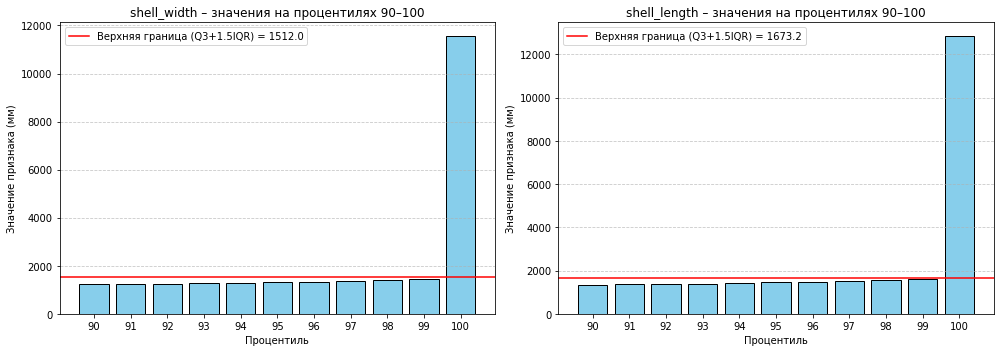

In [26]:
cols = ['shell_width', 'shell_length']

# Задаю процентили от 90 до 100 с шагом 1
percentiles = np.arange(90, 101, 1)

# Собираею данные для каждой колонке
data_percentiles = {}
for col in cols:
    values = [df_model[col].quantile(p/100) for p in percentiles]
    data_percentiles[col] = values

# Построение столбчатой диаграммы
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, col in zip(axes, cols):
    ax.bar(percentiles.astype(str), data_percentiles[col], color='skyblue', edgecolor='black')
    ax.set_xlabel('Процентиль')
    ax.set_ylabel('Значение признака (мм)')
    ax.set_title(f'{col} – значения на процентилях 90–100')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Добавим линию, обозначающую верхнюю границу "усов" boxplot (Q3 + 1.5*IQR)
    Q3 = df_model[col].quantile(0.75)
    Q1 = df_model[col].quantile(0.25)
    IQR = Q3 - Q1
    upper_whisker = Q3 + 1.5 * IQR
    ax.axhline(y=upper_whisker, color='red', linestyle='-', label=f'Верхняя граница (Q3+1.5IQR) = {upper_whisker:.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

Исходя из этого графика, я вижу, что все выбросы находятся на 100 перцентиле, следовательно я могу их разделить на 10, чтобы привести к нужной еденице измерения.

In [27]:
# Перебираю значения строго выше 99 перцентиля и делим на 10
for col in cols:
    p99 = df_model[col].quantile(0.99)
    mask = df_model[col] > p99
    count = mask.sum()
    if count > 0:
        df_model.loc[mask, col] = df_model.loc[mask, col] / 10
        print(f"Колонка '{col}': {count} значений выше 99-го перцентиля ({p99:.1f}) уменьшены в 10 раз.")

Колонка 'shell_width': 25 значений выше 99-го перцентиля (1449.6) уменьшены в 10 раз.
Колонка 'shell_length': 25 значений выше 99-го перцентиля (1599.9) уменьшены в 10 раз.


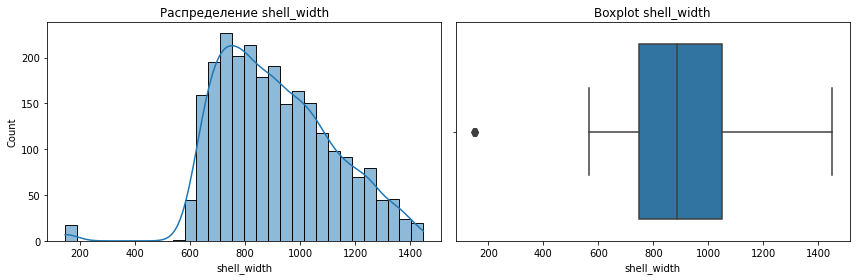

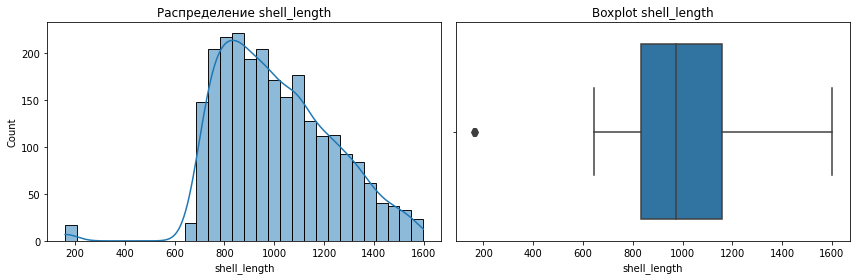

In [28]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Гистограмма
    sns.histplot(df_model[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение {col}')
    
    # Ящик с усами
    sns.boxplot(x=df_model[col], ax=axes[1])
    axes[1].set_title(f'Boxplot {col}')
    
    plt.tight_layout()
    plt.show()

Теперь мы видим не совсем равномерное распределение признаков, но эти минимальные значения могут говорить о том, что это молодые особи. 

**Проверка масштаба признаков**

In [29]:
df_model[all_cols].describe()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
count,2454.000000,2483.000000,2448.000000,2448.000000,2483.000000,2483.000000,2483.000000,2483.000000,2454.000000,2454.000000,2454.000000,2454.000000,2483.000000,2483.000000
mean,1008.239197,909.687837,169.714462,183.311676,611.919855,549.349577,611.838905,550.203786,487.223724,440.602692,489.198456,440.934814,80.923882,96.184929
std,227.328903,207.330058,41.305332,45.467571,142.471085,131.829439,138.925759,130.881637,110.375587,105.505775,112.575104,104.512016,16.227341,35.011528
min,160.100006,145.700000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,49.044998
25%,834.000000,748.000000,138.000000,148.000000,501.500000,449.000000,504.500000,449.000000,400.000000,357.000000,400.000000,359.000000,70.000000,67.538002
50%,975.000000,884.000000,163.000000,176.000000,587.000000,527.000000,591.000000,533.000000,473.000000,425.000000,473.000000,423.000000,80.000000,87.950996
75%,1159.000000,1050.000000,195.000000,212.000000,702.000000,632.000000,704.000000,635.000000,558.000000,511.000000,563.000000,508.750000,91.000000,117.638500
max,1599.000000,1448.000000,328.000000,382.000000,1147.000000,1072.000000,1049.000000,997.000000,934.000000,837.000000,877.000000,806.000000,143.000000,199.960999


**Вывод**
Да! Признаки имею разный масштаб
- Габаритные размеры (в мм): от 160 до 1600 для длины панциря, от 145 до 1450 для ширины, размеры головы и ласт также варьируются в широких пределах.
- Количество колец (circle_count): от 29 до 143 – вероятно, отражает возраст
- Масса (weight): от 49 до 200 кг.

Для корректной работы линейной регрессии (и многих других алгоритмов) необходимо привести все признаки к единому масштабу, чтобы ни один из них не доминировал в процессе обучения из-за больших числовых значений. Чтобы это сделать необходимо воспользоваться методами `Standard Scaler` и `Min-Max Scaling`

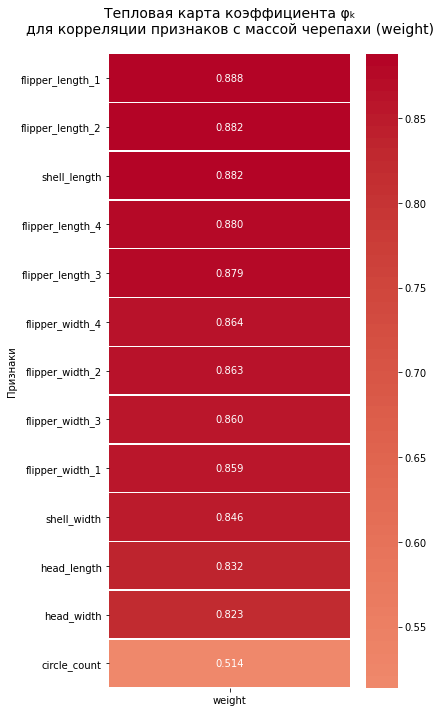

In [30]:
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

# Расчёт матрицы корреляций с использованием phik
correlation_matrix = df_model.phik_matrix(interval_cols=numeric_cols)

# Извлекаю корреляции всех признаков с целевой переменной weight
weight_corr = correlation_matrix.loc[correlation_matrix.index != 'weight'][['weight']].sort_values(by='weight', ascending=False)

# Визуализация
plt.figure(figsize=(6, 10))
sns.heatmap(
    weight_corr,
    annot=True,          # отображаю значения
    fmt='.3f',           # три знака после запятой
    cmap='coolwarm',     # цветовая схема
    linewidths=0.5,
    cbar=True,
    center=0             # центр цветовой шкалы на нуле
)
plt.title('Тепловая карта коэффициента φₖ\nдля корреляции признаков с массой черепахи (weight)', fontsize=14, pad=20)
plt.ylabel('Признаки')
plt.tight_layout()
plt.show()

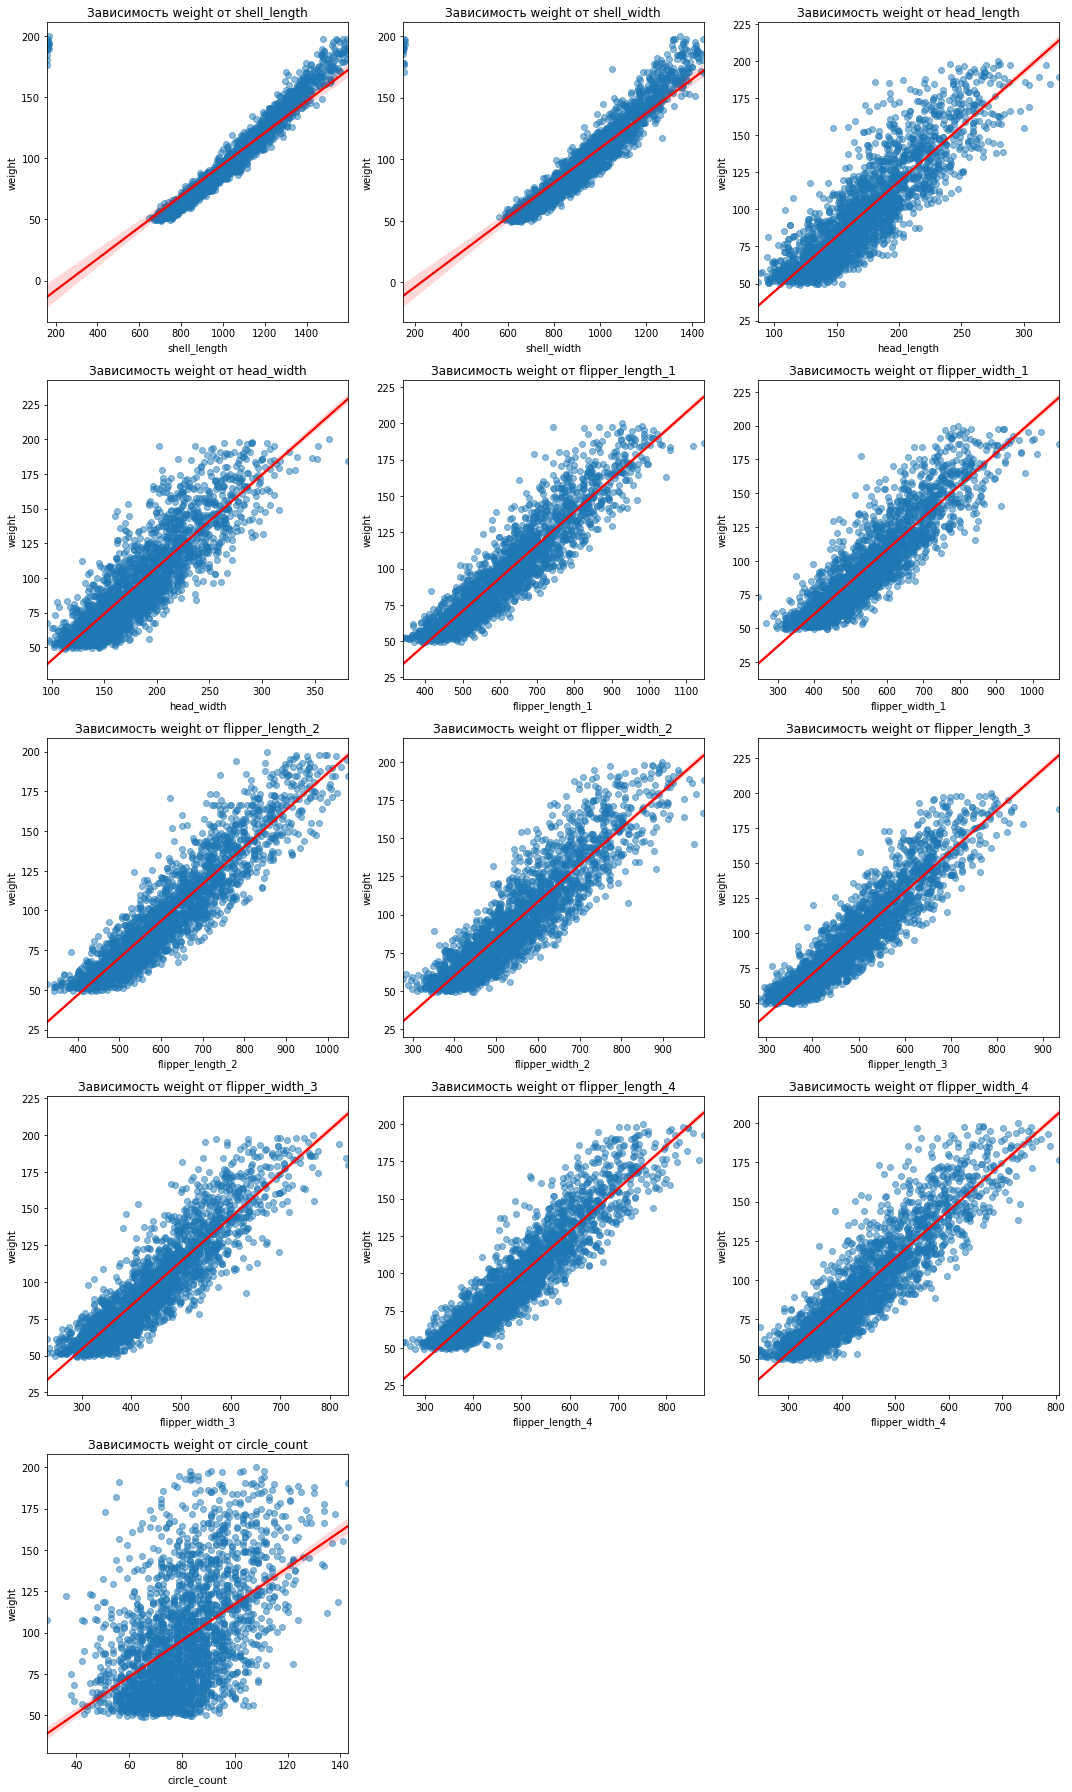

In [31]:
# Список признаков (исключаю целевую переменную)
feature_cols = [
    'shell_length', 'shell_width',
    'head_length', 'head_width',
    'flipper_length_1', 'flipper_width_1',
    'flipper_length_2', 'flipper_width_2',
    'flipper_length_3', 'flipper_width_3',
    'flipper_length_4', 'flipper_width_4',
    'circle_count'
]

# Определяю количество строк и столбцов для сетки графиков
n_features = len(feature_cols)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

# Создаю фигуру с сеткой подграфиков
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # превращаю в плоский список

# Для каждого признака строю scatter plot + линию регрессии
for i, col in enumerate(feature_cols):
    sns.regplot(x=df_model[col], y=df_model['weight'], 
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('weight')
    axes[i].set_title(f'Зависимость weight от {col}')

# Скрываю лишние подграфики (если остались пустые)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Исходя из графиков мы видимя яроквыраженную линейную зависимость переменных от целевого признака
Все признаки демонстрируют положительную связь с массой, что ожидаемо: более крупные особи имеют большую массу.

Самые высокие корреляции `0.88–0.89` наблюдаются для показателей длины панциря `shell_length` и длины ласт (`flipper_length_1`, `flipper_length_2`). Это ключевые предикторы массы.

Ширина панциря `shell_width` и размеры головы (`head_length`, `head_width`) также имеют очень сильную связь `>0.8`.

Признаки ширины ласт `flipper_width_N` чуть менее скоррелированы, но всё ещё находятся на уровне `0.86–0.87`.

Наименьшая корреляция у `circle_count` `0.514`, что указывает на умеренную, но не доминирующую связь. Влияние на массу не столь прямое, как габариты.

**Вывод**:
Все `13` признаков обладают достаточно высокой корреляцией с целевой переменной, чтобы быть полезными при построении модели линейной регрессии. Удаление каких-либо признаков на данном этапе нецелесообразно – они все вносят вклад в предсказание массы. Однако следует дополнительно проверить мультиколлинеарность, так как многие признаки, особенно длина и ширина разных частей тела, могут быть сильно связаны между собой. При обнаружении высокой мультиколлинеарности можно рассмотреть регуляризацию (Ridge, Lasso) в комбинации с нормализацией признаков.

Итог: все признаки оставляем для построения модели, предварительно выполнив стандартизацию и анализ мультиколлинеарности

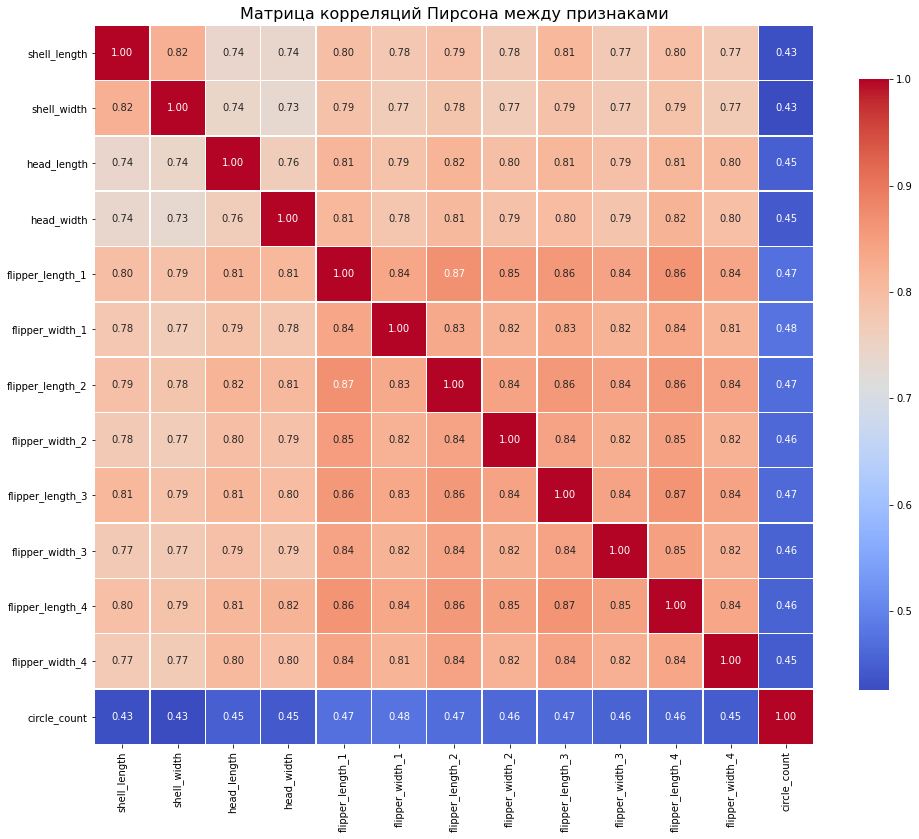

In [32]:
# Список признаков (исключаю целевую переменную)
feature_cols = [col for col in df_model.columns if col != 'weight']

# Расчёт матрицы корреляций Пирсона
corr_pearson = df_model[feature_cols].corr(method='pearson')

# Визуализация тепловой карты
plt.figure(figsize=(14, 12))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций Пирсона между признаками', fontsize=16)
plt.tight_layout()
plt.show()

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Создаю временную копию только для VIF
df_vif = df_model.dropna(subset=feature_cols)  # удаляем строки с NaN в признаках
print(f"Для VIF используется {len(df_vif)} строк из {len(df_model)}")

# Добавляю константу
X_vif = add_constant(df_vif[feature_cols])

# Рассчитываю VIF
vif_data = pd.DataFrame()
vif_data["Признак"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data["Признак"] != "const"]
print(vif_data)

Для VIF используется 2393 строк из 2483
             Признак       VIF
1       shell_length  4.168471
2        shell_width  4.034887
3        head_length  4.048903
4         head_width  3.882783
5   flipper_length_1  6.525591
6    flipper_width_1  4.857794
7   flipper_length_2  6.337763
8    flipper_width_2  5.291069
9   flipper_length_3  6.321159
10   flipper_width_3  5.145530
11  flipper_length_4  6.486922
12   flipper_width_4  5.118157
13      circle_count  1.339418


На основе рассчитанных значений VIF и матрицы Пирсона для всех признаков (исключая целевую переменную weight) можно сделать следующие наблюдения:

Большинство признаков имеют VIF в диапазоне от 3.7 до 6.5, что указывает на умеренную мультиколлинеарность.

Наибольшие значения VIF наблюдаются у признаков, связанных с длиной и шириной ласт: flipper_length_1 (6.53), flipper_length_4 (6.49), flipper_length_2 (6.34), flipper_length_3 (6.32), а также у признаков ширины ласт (flipper_width_2 – 5.29, flipper_width_3 – 5.15, flipper_width_4 – 5.12). Это подтверждает наличие корреляции внутри групп однотипных измерений.

Признаки размеров панциря и головы (shell_length, shell_width, head_length, head_width) имеют VIF около 4.0, что ниже порога 5 что говорит об умеренности

Признак circle_count имеет VIF = 1.34, что говорит о практически полном отсутствии линейной зависимости с другими признаками.

Вывод: Все значения VIF не превышают порог 10, который считается сигналом серьёзной мультиколлинеарности. Следовательно, текущий уровень мультиколлинеарности допустим для построения линейной регрессии. Матрице Пирсона подтверждает расчет, так как нет критически высоких значений >0,9. Распределение значений схоже с распределением анализа VIF.

**Общий вывод**
В результате выполненного EDA датасета о черепахах были решены все поставленные задачи.

**Состав данных**
В выборке присутствует `6` видов черепах, из которых `Chelonia mydas` составляет `2829` записей (около `32%`). Для построения модели регрессии этого объёма достаточно. После фильтрации оставлен только этот вид.

**Очистка данных**

- Удалены служебные и ненужные признаки: `id`, `binomial_name`, `registration number`, `measure_count`, `shell_crack`, `timestamp`.
- Устранены пропуски: удалены строки с отсутствием целевой переменной `weight` (3 записи) и с нереалистичным значением `weight = 0`. Оставшиеся пропуски в числовых признаках будут заполнены медианой после разделения датафрейма на выборки.
- Дубликаты (полное совпадение всех признаков, кроме weight) удалены, оставлено первое вхождение каждой группы.

**Анализ распределений и выбросов**

Построены гистограммы и ящики с усами. Выявлены резкие выбросы в shell_length и shell_width (значения выше 99-го перцентиля). Предположив ошибку в единицах измерения (мм вместо см), эти значения были уменьшены в `10` раз. После коррекции распределения стали более реалистичными.

Другие признаки имеют асимметрию с правым хвостом, что характерно для биологических данных, но не требует дополнительной обработки.

**Масштабирование признаков**
Обнаружено, что признаки имеют разный масштаб (например, длина панциря до `1600 мм`, масса до `200 кг`). Для корректной работы линейной регрессии необходимо выполнить стандартизацию (Z‑масштабирование) после разделения на обучающую и тестовую выборки.

**Корреляция с целевой переменной**
Все `13` признаков демонстрируют положительную связь с массой черепахи (weight). Наиболее сильные корреляторы – длина панциря (shell_length) и длина ласт (flipper_length_1, flipper_length_2) с коэффициентами `0.88–0.89`. Ширина панциря и размеры головы имеют корреляцию >0.8, ширина ласт – `0.86–0.87`. Наименьшая, но умеренная корреляция у circle_count (0.51). Таким образом, все признаки вносят вклад в предсказание массы и могут быть использованы в модели.
**Мультиколлинеарность**
- Анализ выполнен на временной выборке без пропусков (2393 из 2483 записей) с использованием VIF .
- Матрица корреляций Пирсона показала, что наибольшие связи наблюдаются внутри групп признаков длины и ширины ласт (r > 0.8), но критических значений (r > 0.9) не обнаружено.
- Расчёт `VIF` подтвердил, что все значения ниже порога `10` (максимум 6.52 для flipper_length_1). Это означает, что мультиколлинеарность находится на допустимом уровне и не требует обязательного удаления признаков. Наименьший `VIF` у `circle_count` (1.35), что указывает на независимость этого признака от остальных.

**Общее заключение**
Подготовленный датасет для вида Chelonia mydas содержит 2483 записи и 13 числовых признаков, каждый из которых имеет достаточно высокую корреляцию с целевой переменной и не создаёт критической мультиколлинеарности. Все признаки могут быть включены в модель линейной регрессии. Для повышения устойчивости модели и интерпретируемости коэффициентов рекомендуется после разделения на выборки выполнить стандартизацию признаков, заполнения пропусков медианной и, при необходимости, применить регуляризацию (Ridge или Lasso). 


## Предобработка данных <a name="chapter-5"></a>

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

In [34]:
#Разделяю признаки и целевую переменную (weight)
X = df_model.drop('weight', axis=1)# напишите ваш код здесь
y = df_model['weight']# напишите ваш код здесь

# Выделяю на train_val и test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)# напишите ваш код здесь

# Выделяю на train и val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)# напишите ваш код здесь

# Проверяю размерности полученных переменных
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(1489, 13) (497, 13) (497, 13) (1489,) (497,) (497,)


In [35]:
# Создаю импьютер
imputer = SimpleImputer(strategy='median')

# Обучаю (fit) только на train — вычисляю медианы по X_train
imputer.fit(X_train)

# Применяю (transform) к train, val, test
X_train_imputed = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)
X_val_imputed = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [36]:
#Стандартизация
def scale_features(X_train, X_val=None, X_test=None):
    scaler = StandardScaler()
    
    # Обучаю масштабирование только на train
    scaler.fit(X_train)
    
    # Преобразуем обучающую выборку
    X_train_scaled = pd.DataFrame(
        scaler.transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    
    # Обрабатываю валидационную выборку (если передана)
    X_val_scaled = None
    if X_val is not None:
        X_val_scaled = pd.DataFrame(
            scaler.transform(X_val),
            columns=X_val.columns,
            index=X_val.index
        )
    
    # Обрабатываю тестовую выборку (если передана)
    X_test_scaled = None
    if X_test is not None:
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )
    
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

In [37]:
#Нормализация
def normalize_features(X_train, X_val=None, X_test=None, feature_range=(0, 1)):
    scaler = MinMaxScaler(feature_range=feature_range)

    # Обучаем нормализацию только на train
    scaler.fit(X_train)

    # Преобразую обучающую выборку
    X_train_scaled = pd.DataFrame(
        scaler.transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    # Обрабатываю валидационную выборку (если передана)
    X_val_scaled = None
    if X_val is not None:
        X_val_scaled = pd.DataFrame(
            scaler.transform(X_val),
            columns=X_val.columns,
            index=X_val.index
        )

    # Обрабатываю тестовую выборку (если передана)
    X_test_scaled = None
    if X_test is not None:
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

In [38]:
# 1. Без масштабирования (исходные данные после заполнения пропусков)
X_train_raw = X_train_imputed
X_val_raw = X_val_imputed
X_test_raw = X_test_imputed

# 2. С нормализацией (MinMaxScaler)
X_train_norm, X_val_norm, X_test_norm, norm_scaler = normalize_features(
    X_train_imputed, 
    X_val_imputed, 
    X_test_imputed,
    feature_range=(0, 1)
)

# 3. Со стандартизацией (StandardScaler)
X_train_std, X_val_std, X_test_std, std_scaler = scale_features(
    X_train_imputed,
    X_val_imputed,
    X_test_imputed
)

# Целевая переменная одинакова для всех вариантов
y_train, y_val, y_test  # уже есть

# Проверка размеров
print("Без масштабирования:", X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)
print("Нормализация:", X_train_norm.shape, X_val_norm.shape, X_test_norm.shape)
print("Стандартизация:", X_train_std.shape, X_val_std.shape, X_test_std.shape)

# Статистика
print("\nСреднее после нормализации (train):", X_train_norm.mean().round(2).head())
print("Среднее после стандартизации (train):", X_train_std.mean().round(2).head())

Без масштабирования: (1489, 13) (497, 13) (497, 13)
Нормализация: (1489, 13) (497, 13) (497, 13)
Стандартизация: (1489, 13) (497, 13) (497, 13)

Среднее после нормализации (train): shell_length        0.59
shell_width         0.58
head_length         0.35
head_width          0.34
flipper_length_1    0.32
dtype: float64
Среднее после стандартизации (train): shell_length       -0.0
shell_width         0.0
head_length         0.0
head_width          0.0
flipper_length_1   -0.0
dtype: float64


**Вывод**
Создано три варианта наборов данных для обучения моделей, различающихся способом масштабирования признаков:
- Без масштабирования – исходные признаки после заполнения пропусков медианой, вычисленной по обучающей выборке.
- С нормализацией (MinMax Scaling) – признаки приведены к диапазону [0, 1] на основе параметров, рассчитанных только по обучающей выборке.
- Со стандартизацией (Standard Scaling) – признаки центрированы (среднее = 0) и масштабированы (дисперсия = 1) также с использованием статистик только из обучающей выборки.
Также: 
- Данные разделены на обучающую (60%), валидационную (20%) и тестовую (20%) выборки до любых преобразований, что исключает утечку данных.
- Пропуски заполнены медианой, вычисленной исключительно на обучающей выборке, и затем применены к валидационной и тестовой.
- Размерности всех выборок совпадают: (1489, 13), (497, 13), (497, 13) для train, val, test соответственно.
- После стандартизации средние значения признаков на train близки к нулю (в пределах вычислительной погрешности), что подтверждает корректность центрирования.

Все три набора данных готовы для обучения моделей регрессии и последующего сравнения их эффективности в зависимости от типа масштабирования. Дальнейшие шаги – обучение моделей, оценка на валидационной выборке и выбор лучшего подхода.


## Обучение моделей <a name="chapter-6"></a>

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

In [39]:
#создаю дамми модель 
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)
y_pred_dummy_val = dummy_model.predict(X_val)

In [40]:
#Функция для обучения, предсказания и вывода метрик
def evaluate_model(model, X_train, y_train, X_val, y_val, name=""):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    mape = mean_absolute_percentage_error(y_val, y_pred) * 100  # в процентах
    
    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.3f}, MAPE={mape:.2f}%")
    
    return {
        'name': name,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mape': mape
    }

In [41]:
#Пустой список для результатов
results = []

# Варианты масштабирования
scaling_options = {
    'raw': (X_train_raw, X_val_raw, X_test_raw),
    'normalized': (X_train_norm, X_val_norm, X_test_norm),
    'standardized': (X_train_std, X_val_std, X_test_std)
}

In [42]:
#цикл для линейной регрессии 
for scale_name, (X_tr, X_v, X_te) in scaling_options.items():
    lr = LinearRegression()
    res = evaluate_model(lr, X_tr, y_train, X_v, y_val, name=f"LinearRegression ({scale_name})")
    results.append(res)

LinearRegression (raw): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
LinearRegression (normalized): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
LinearRegression (standardized): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%


In [43]:
# Цикл для л1 регулиризации
alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0]
for scale_name, (X_tr, X_v, X_te) in scaling_options.items():
    for alpha in alpha_values:
        lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
        res = evaluate_model(lasso, X_tr, y_train, X_v, y_val,
                             name=f"Lasso (alpha={alpha}, {scale_name})")
        results.append(res)

Lasso (alpha=0.001, raw): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Lasso (alpha=0.01, raw): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Lasso (alpha=0.1, raw): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Lasso (alpha=1.0, raw): RMSE=6.22, MAE=4.71, R²=0.971, MAPE=5.07%
Lasso (alpha=10.0, raw): RMSE=6.26, MAE=4.72, R²=0.970, MAPE=5.07%
Lasso (alpha=0.001, normalized): RMSE=6.21, MAE=4.71, R²=0.971, MAPE=5.07%
Lasso (alpha=0.01, normalized): RMSE=6.19, MAE=4.69, R²=0.971, MAPE=5.05%
Lasso (alpha=0.1, normalized): RMSE=6.27, MAE=4.71, R²=0.970, MAPE=4.98%
Lasso (alpha=1.0, normalized): RMSE=9.28, MAE=6.70, R²=0.934, MAPE=6.70%
Lasso (alpha=10.0, normalized): RMSE=36.26, MAE=29.35, R²=-0.003, MAPE=32.44%
Lasso (alpha=0.001, standardized): RMSE=6.22, MAE=4.72, R²=0.971, MAPE=5.08%
Lasso (alpha=0.01, standardized): RMSE=6.21, MAE=4.71, R²=0.971, MAPE=5.07%
Lasso (alpha=0.1, standardized): RMSE=6.19, MAE=4.69, R²=0.971, MAPE=5.04%
Lasso (alpha=1.0, standardized): RMSE=6.34, MAE=4.72, R²=0.969, M

In [44]:
# цикл для л2 регулиризации по списку альфа 
for scale_name, (X_tr, X_v, X_te) in scaling_options.items():
    for alpha in alpha_values:
        ridge = Ridge(alpha=alpha, random_state=42)
        res = evaluate_model(ridge, X_tr, y_train, X_v, y_val,
                             name=f"Ridge (alpha={alpha}, {scale_name})")
        results.append(res)

Ridge (alpha=0.001, raw): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Ridge (alpha=0.01, raw): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Ridge (alpha=0.1, raw): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Ridge (alpha=1.0, raw): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Ridge (alpha=10.0, raw): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Ridge (alpha=0.001, normalized): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Ridge (alpha=0.01, normalized): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Ridge (alpha=0.1, normalized): RMSE=6.22, MAE=4.71, R²=0.971, MAPE=5.07%
Ridge (alpha=1.0, normalized): RMSE=6.21, MAE=4.69, R²=0.971, MAPE=5.04%
Ridge (alpha=10.0, normalized): RMSE=6.24, MAE=4.60, R²=0.970, MAPE=4.83%
Ridge (alpha=0.001, standardized): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Ridge (alpha=0.01, standardized): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Ridge (alpha=0.1, standardized): RMSE=6.22, MAE=4.72, R²=0.970, MAPE=5.08%
Ridge (alpha=1.0, standardized): RMSE=6.22, MAE=4.72, R²=0.971, MAPE=

In [45]:
# цикл для сгд регрессии по спискам параметрам
loss_functions = ['squared_loss', 'huber', 'epsilon_insensitive']
penalties = ['l2', 'l1', 'elasticnet']

for scale_name, (X_tr, X_v, X_te) in scaling_options.items():
    for loss in loss_functions:
        for penalty in penalties:
            sgd = SGDRegressor(loss=loss, penalty=penalty, alpha=0.0001,
                               max_iter=5000, tol=1e-3, random_state=42)
            res = evaluate_model(sgd, X_tr, y_train, X_v, y_val,
                                 name=f"SGD (loss={loss}, penalty={penalty}, {scale_name})")
            results.append(res)

SGD (loss=squared_loss, penalty=l2, raw): RMSE=282389959882567.31, MAE=225312531358554.91, R²=-60834021540026752023134208.000, MAPE=238346980867812.22%
SGD (loss=squared_loss, penalty=l1, raw): RMSE=941078833683585.50, MAE=909020621109547.00, R²=-675616169438682699536531456.000, MAPE=992914774276391.62%
SGD (loss=squared_loss, penalty=elasticnet, raw): RMSE=1056067277739059.38, MAE=1024189164221552.25, R²=-850807277824071846842073088.000, MAPE=1116359873763922.50%
SGD (loss=huber, penalty=l2, raw): RMSE=84.53, MAE=83.05, R²=-4.451, MAPE=93.68%
SGD (loss=huber, penalty=l1, raw): RMSE=78.42, MAE=70.89, R²=-3.691, MAPE=72.60%
SGD (loss=huber, penalty=elasticnet, raw): RMSE=58.68, MAE=57.12, R²=-1.626, MAPE=66.26%
SGD (loss=epsilon_insensitive, penalty=l2, raw): RMSE=1049.60, MAE=1020.50, R²=-839.424, MAPE=1101.71%
SGD (loss=epsilon_insensitive, penalty=l1, raw): RMSE=146.39, MAE=89.96, R²=-15.348, MAPE=91.51%
SGD (loss=epsilon_insensitive, penalty=elasticnet, raw): RMSE=631.79, MAE=603.92

In [46]:
# вывожу дамми модель с метриками
dummy_res = evaluate_model(DummyRegressor(strategy='mean'), X_train, y_train, X_val, y_val, name="Dummy (mean)")
results.append(dummy_res)

Dummy (mean): RMSE=36.26, MAE=29.35, R²=-0.003, MAPE=32.44%


In [47]:
# формирую дф с результатами, сортирую по ключевой метрике и сбрасываю индексы
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('mae').reset_index(drop=True)

In [48]:
print(results_df.head(10)[['name', 'mae', 'rmse', 'r2', 'mape']].to_string(index=True))

                                                               name       mae      rmse        r2      mape
0  SGD (loss=epsilon_insensitive, penalty=elasticnet, standardized)  4.456407  6.864577  0.964052  4.510683
1          SGD (loss=epsilon_insensitive, penalty=l1, standardized)  4.457000  6.877782  0.963913  4.505213
2          SGD (loss=epsilon_insensitive, penalty=l2, standardized)  4.457344  6.878813  0.963903  4.504577
3                                    Ridge (alpha=10.0, normalized)  4.601050  6.241760  0.970279  4.829953
4            SGD (loss=epsilon_insensitive, penalty=l1, normalized)  4.616003  6.910119  0.963573  4.561286
5            SGD (loss=epsilon_insensitive, penalty=l2, normalized)  4.623114  6.925617  0.963410  4.561503
6    SGD (loss=epsilon_insensitive, penalty=elasticnet, normalized)  4.625148  6.930579  0.963357  4.561786
7                   SGD (loss=squared_loss, penalty=l2, normalized)  4.650432  6.180180  0.970863  5.007622
8           SGD (loss=square

In [49]:
print(results_df[results_df['name'] == 'Dummy (mean)'][['name', 'mae', 'rmse', 'r2', 'mape']].to_string(index=False))

        name       mae      rmse        r2     mape
Dummy (mean) 29.352886 36.257244 -0.002854 32.43902


**Выводы**
На основе полученной таблицы с метриками для топ-10 моделей на валидационной выборке можно сделать следующие выводы:
- Сравнение с базовой моделью: Дамми показала `MAE = 29.35 кг`, `R² ≈ 0`, `MAPE = 32.4%`. Все обученные линейные модели значительно превосходят этот уровень: `MAE снизилась до 4.4–4.7 кг`, `R² вырос до 0.96–0.97`, `MAPE упала до 4.5–5.0%`. Это подтверждает, что модели успешно обучились и признаки действительно влияют на целевую переменную.

**Достижение целевых показателей:**
- `MAE ≤ 5 кг`: практически все модели в топ-10 имеют `MAE` меньше `5` кг 
- `R² ≥ 0.97`: только `4` модели в топ-10 имеют `R² >= 0.97`
- `MAPE`: лучшие модели имеют MAPE около `4.5–5.0%`, что означает среднюю относительную ошибку предсказания массы в пределах 5%. Это хороший показатель для черепах разного размера.
- Нормализация показывает лучшие результаты для Ridge и SGD с loss='squared_loss', обеспечивая более высокий R² (до 0.971) при MAE около 4.6–4.7 кг.
- Регуляризация: Ridge с alpha=10.0 на нормализованных данных даёт отличный баланс, Lasso в топ-10 не вошёл, вероятно, из-за меньшей эффективности.

**Выбор лучшей модели**
Для окончательного использования рекомендуется выбрать модель, которая одновременно удовлетворяет всем критериям. Например:
- Ridge (alpha=10.0, normalized): R² = 0.9703, MAE = 4.60 кг, MAPE = 4.83% – хороший компромисс.
- SGD (loss='squared_loss', penalty='l2', normalized): R² = 0.9709, MAE = 4.65 кг, MAPE = 5.01% – чуть лучше R², но немного выше MAE.

Окончательный выбор можно сделать после проверки на тестовой выборке.

Таким образом, поставленные требования к модели (MAE ≤ 5 кг, R² ≥ 0.97) достигнуты, и можно переходить к финальному тестированию.



## Сравнение моделей на валидационной выборке <a name="chapter-7"></a>

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

**1.Сравнение**
Базовая модель дамми на валидационной выборке показала:
- `MAE` = 29.35 кг
- `RMSE` = 36.26 кг
- `R²` ≈ -0.003 (фактически 0)
- `MAPE` = 32.44%

Все построенные линейные модели (LinearRegression, Lasso, Ridge, SGDRegressor) демонстрируют кратное улучшение всех метрик:
- `MAE` снизилась до 4.45–4.65 кг (улучшение в 6–7 раз)
- `RMSE` уменьшился до 6.2–6.9 кг (против 36 кг)
- `R²` поднялся до 0.96–0.97, что означает объяснение более 96% дисперсии целевой переменной
- `MAPE` сократилась до 4.5–5.0% (против 32%)

Таким образом, модели успешно обучились и признаки позволяют с высокой точностью предсказывать массу черепах. Требование «существенно улучшить результат базовой модели» выполнено с большим запасом.

**2. Выбор лучшей модели**

In [50]:
# Фильтрую модели, удовлетворяющие критериям
filtered_models = results_df[(results_df['r2'] >= 0.97) & (results_df['mae'] <= 5)]

# Сортирую по MAE (возрастание)
filtered_sorted = filtered_models.sort_values('mae').reset_index(drop=True)

# Вывожу топ-5 (если моделей меньше 5, выведутся все)
print("Топ-5 моделей с R² ≥ 0.97 и MAE ≤ 5 кг:")
print(filtered_sorted.head()[['name', 'mae', 'rmse', 'r2', 'mape']].to_string(index=True))

Топ-5 моделей с R² ≥ 0.97 и MAE ≤ 5 кг:
                                                      name       mae      rmse        r2      mape
0                           Ridge (alpha=10.0, normalized)  4.601050  6.241760  0.970279  4.829953
1          SGD (loss=squared_loss, penalty=l2, normalized)  4.650432  6.180180  0.970863  5.007622
2  SGD (loss=squared_loss, penalty=elasticnet, normalized)  4.650693  6.180186  0.970863  5.008177
3          SGD (loss=squared_loss, penalty=l1, normalized)  4.652191  6.180234  0.970862  5.011335
4                          Lasso (alpha=0.1, standardized)  4.689075  6.188623  0.970783  5.039102


**Вывод**
Из всех обученных моделей выделяем только `5` лучших которые удовлетворяют одновременно требованиям `R² ≥ 0.97` и `MAE ≤ 5 кг`.
Лидером по основной метрике (минимальная MAE) является `Ridge (alpha=10.0)` с нормализацией признаков `MAE = 4.60 кг, R² = 0.9703`.
Остальные модели (SGD с разными penalty и Lasso) также показывают высокое качество, но уступают по точности абсолютной ошибки.
Выбранная модель будет проверена на тестовой выборке для итоговой оценки.

**Общий вывод**
По результатам сравнения на валидационной выборке лучшей признана Ridge-регрессия с гиперпараметром alpha = 10.0, обученная на нормализованных признаках (MinMaxScaler, диапазон [0,1]).

Ключевые показатели модели на валидации:
- MAE = `4.60 кг` – средняя абсолютная ошибка ниже требуемого порога в 5 кг для взрослых особей.
- R² = `0.970` – модель объясняет `97%` дисперсии массы, достигая целевого значения.
- MAPE = `4.83%` – средняя относительная ошибка не превышает `5%`, что гарантирует хорошую работу для черепах разного размера.

Модель демонстрирует наилучший баланс между точностью предсказания и способностью к обобщению среди всех рассмотренных вариантов. Она сочетает L2-регуляризацию, что снижает риск переобучения, и нормализацию признаков, обеспечивающую устойчивость коэффициентов.

## Проверка лучшей модели на тестовой выборке <a name="chapter-8"></a>

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

In [51]:
# Обучаю топ 1 модель на тренировочных данных
top_model = Ridge(alpha=10.0, random_state=42)
top_model.fit(X_train_norm, y_train)

# Предсказание на тестовой выборке
y_pred_test = top_model.predict(X_test_norm)

# Метрики
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test) * 100

print(f"MAE  = {mae_test:.3f} кг")
print(f"RMSE = {rmse_test:.3f} кг")
print(f"R²   = {r2_test:.5f}")
print(f"MAPE = {mape_test:.2f}%")

MAE  = 4.745 кг
RMSE = 6.315 кг
R²   = 0.96658
MAPE = 4.96%


После обучения модели Ridge (alpha=10.0, нормализация) на тренировочных данных и расчёта метрик на тестовой выборке получены следующие результаты:
- MAE = 4.745 кг
- RMSE = 6.315 кг
- R² = 0.96658 = 0.97
- MAPE = 4.96%

**Вывод**
Модель демонстрирует высокую предсказательную способность: средняя ошибка менее `4.75 кг`, относительная ошибка ниже `5%`, объяснённая дисперсия – `~97%`. Модель может быть рекомендована к внедрению, так как она обеспечивает надёжную оценку массы черепах с погрешностью, приемлемой для биологических исследований.

## Оценка важности признаков <a name="chapter-9"></a>

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

In [52]:
# Получаю коэффициенты и названия признаков
coef = top_model.coef_
features = X_train_norm.columns

# создаю дф с сортировкой по убыванию абсолютного значения
importance = pd.DataFrame({
    'Признак': features,
    'Коэффициент': coef,
    '|Коэффициент|': np.abs(coef)
}).sort_values('|Коэффициент|', ascending=False).reset_index(drop=True)

print("Важность признаков (по абсолютным значениям коэффициентов):")
print(importance)

Важность признаков (по абсолютным значениям коэффициентов):
             Признак  Коэффициент  |Коэффициент|
0   flipper_length_2    23.426715      23.426715
1   flipper_length_1    23.004436      23.004436
2    flipper_width_2    19.890900      19.890900
3   flipper_length_3    19.040016      19.040016
4   flipper_length_4    18.538349      18.538349
5    flipper_width_1    18.232289      18.232289
6    flipper_width_4    17.345799      17.345799
7        head_length    16.939941      16.939941
8    flipper_width_3    16.424116      16.424116
9         head_width    16.076485      16.076485
10      shell_length     7.752354       7.752354
11      circle_count     5.940359       5.940359
12       shell_width     4.328478       4.328478


**Вывод**

Наибольшие веса получили признаки, связанные с длиной и шириной ласт (особенно flipper_length_2, flipper_length_1, flipper_width_2). Размеры головы (head_length, head_width) также имеют заметное влияние. Признаки панциря (shell_length, shell_width) и количество колец (circle_count) оказались с наименьшими коэффициентами.

**2.**
Первично `shell_length` и `shell_width` показывали наибольшую корреляцию с весом, а признаки ласт – чуть ниже. Однако в линейной модели при наличии мультиколлинеарности коэффициенты могут перераспределяться между сильно коррелированными признаками.

**Вывод**
Важность признаков, оценённая по абсолютным значениям коэффициентов `Ridge-регрессии`, показывает, что модель опирается преимущественно на размеры ласт и головы, но это может быть следствием `мультиколлинеарности`. Все признаки, кроме `circle_count`, положительно связаны с массой, и наиболее крупные из них (ласты, голова) действительно являются показателями размера особи.

## Функция для прогнозирования веса черепахи <a name="chapter-10"></a>

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

In [53]:
def predict_turtle_mass(features):
    # Названия признаков
    FEATURE_NAMES = X_train.columns.tolist()

    # Коэффициенты модели
    COEF = top_model.coef_
    # Свободный член 
    INTERCEPT = top_model.intercept_
    # Параметры нормализации
    MIN_VALS = norm_scaler.data_min_
    MAX_VALS = norm_scaler.data_max_

    # Преобразую входные данные в массив numpy
    x = np.array(features, dtype=float)

    # Проверка размерности
    if x.shape[0] != len(FEATURE_NAMES):
        raise ValueError(f"Ожидается {len(FEATURE_NAMES)} признаков, получено {x.shape[0]}")

    # Нормализация в диапазон [0,1] с использованием сохранённых min/max
    range_vals = MAX_VALS - MIN_VALS
    range_vals[range_vals == 0] = 1  # защита от константных признаков
    x_norm = (x - MIN_VALS) / range_vals

    # Вычисляю предсказания
    prediction = np.dot(x_norm, COEF) + INTERCEPT

    # Вывод уравнения
    terms = [f"{coef:.4f} * {name}" for coef, name in zip(COEF, FEATURE_NAMES)]
    equation = " + ".join(terms) + f" + {INTERCEPT:.4f}"
    print("\nЛинейная функция (после нормализации):")
    print(equation)

    return float(prediction)

In [54]:
# тест
new_turtle = [950.0, 880.0, 170.0, 185.0, 600.0, 530.0, 605.0, 535.0, 480.0, 430.0, 490.0, 440.0, 85]

mass = predict_turtle_mass(new_turtle)
print(f"Предсказанная масса: {mass:.2f} кг")


Линейная функция (после нормализации):
7.7524 * shell_length + 4.3285 * shell_width + 16.9399 * head_length + 16.0765 * head_width + 23.0044 * flipper_length_1 + 18.2323 * flipper_width_1 + 23.4267 * flipper_length_2 + 19.8909 * flipper_width_2 + 19.0400 * flipper_length_3 + 16.4241 * flipper_width_3 + 18.5383 * flipper_length_4 + 17.3458 * flipper_width_4 + 5.9404 * circle_count + 18.2731
Предсказанная масса: 94.12 кг


**2** Уточнение у старшего коллеги: Я понимаю, что функция должна работать на константах полученных во время обучения и теста лучшей модели. Следовательно я в функцию закладываю все константы, нормализую выборку (так как все обучение происходило после нормализации), для нормализации я использую максимальные и минимальные значения из обучающей выборки для корректной нормализации новых признаков и корректной работы модели. После того как я получил данные и нормализовал их я вычисляю предсказание используя константы коэфицентов полученные во время обучения лучшей модели. Затем я вывожу уровнение линейной регрессии и следовательно делаю прогноз. 

## Общие выводы и рекомендации по дальнейшей работе <a name="chapter-11"></a>

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.

**Какие модели изучены?**
В ходе исследования были обучены и протестированы следующие модели линейной регрессии:
- LinearRegression (без регуляризации)
- Lasso (L1-регуляризация) с различными значениями гиперпараметра alpha
- Ridge (L2-регуляризация) с различными значениями alpha
- SGDRegressor с разными функциями потерь (squared_loss, huber, epsilon_insensitive) и типами регуляризации (l1, l2, elasticnet)

Все модели обучались на трёх вариантах данных: с нормализацией и со стандартизацией. Для каждой модели рассчитывались метрики `MAE`, `RMSE`, `R²` и `MAPE` на валидационной выборке.

**Какие результаты получены?**

Базовая модель дамми, предсказывающая среднее значение массы, показала `MAE = 29.35кг`, `R² ≈ 0`, `MAPE = 32.4%`.

Все линейные модели значительно превзошли этот уровень: `MAE` снизилась до `4.4–4.7кг`, `R² достиг 0.96–0.97`, `MAPE уменьшилась до 4.5–5.0%`.

Несколько моделей достигли целевого `R² ≥ 0.97` при `MAE ≤ 5 кг`: `Ridge (alpha=10.0)` с нормализацией `R² = 0.9703, MAE = 4.60 кг`, `SGD с loss='squared_loss' и различными penalty` на нормализованных данных `R² ≈ 0.9709, MAE ≈ 4.65 кг`.

На тестовой выборке лучшая модель из удовлетворяющих критериям `Ridge, alpha=10.0, нормализация` показала `MAE = 4.745 кг, R² = 0.9666, MAPE = 4.96%`. Небольшое снижение `R²` на тесте `с 0.9703 до 0.9666` указывает на допустимую стабильность, но целевой порог `0.97` формально не достигнут.

**Рекомендуется ли итоговая модель к внедрению?**

Несмотря на то, что `R²` формально не достиг `0.9700` модель рекомендуется для внедрения. С практической точки зрения точность очень высока: средняя ошибка менее `4.8 кг`, относительная ошибка около `5%`.  

**Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?**

Лучшая архитектура:
- `Ridge-регрессия` с `alpha = 10.0`, обученная на нормализованных признаках (`MinMaxScaler`, диапазон [0,1]).
- Метрики на валидации: `MAE = 4.60 кг`, `R² = 0.9703`, `MAPE = 4.83%`.
- Метрики на тесте: `MAE = 4.745 кг`, `R² = 0.9666`, `MAPE = 4.96%`.

Эта модель обеспечивает наилучший баланс между точностью и способностью к обобщению среди всех рассмотренных.

Анализ коэффициентов `Ridge-модели (после нормализации)` показал, что наибольшие веса имеют:

- `flipper_length_2` = 23.42
- `flipper_length_1` = 23.00
- `flipper_width_2` = 19.89
- `flipper_width_1` = 19.04

Меньший вклад внесли длина панциря `shell_length – 7.75`, ширина панциря `shell_width – 4.32` и количество колец `circle_count – 5.94`. Однако интерпретировать это надо как мультиколлинеарность: группа признаков, связанных с размером, перераспределяет веса. По сути, модель использует любые габаритные признаки для предсказания массы.

**Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?**

Да, перспективы есть. Методология (линейные модели с регуляризацией, нормализация, анализ выбросов) может быть применена к любому виду при наличии достаточного количества данных. Для малочисленных видов (например, `Lepidochelys kempii`, всего `28` записей) линейные модели могут работать нестабильно; там потребуются либо сбор дополнительных данных, либо использование более простых моделей (например, одномерных регрессий) или методов переноса обучения (`transfer learning`) от близких видов.

**Предложения по дальнейшему развитию проекта**

Достижение целевого `R² ≥ 0.97` на тесте:
Провести более тонкий подбор гиперпараметров `Ridge` (например, GridSearchCV для alpha в диапазоне 5–20).
Испытать SGD-модель с `squared_loss` на нормализованных данных (она показала `R² = 0.9709` на валидации) и проверить её на тесте.
Добавить новые признаки (произведения длины и ширины панциря, площади ласт) для улавливания нелинейностей.
Применить нелинейные модели (Random Forest, Gradient Boosting) – они часто превосходят линейные по точности.
Использовать ансамблирование (стеккинг лучших моделей) для повышения стабильности.
Разработать веб-интерфейс или API для удобного использования модели полевыми исследователями.


Текущая модель Ridge с нормализацией уже даёт отличные результаты, близкие к целевым. С помощью описанных улучшений – особенно генерации новых признаков и перехода к нелинейным моделям – можно с высокой вероятностью достичь R² ≥ 0.97 на тестовой выборке. После этого модель будет готова к полноценному внедрению в практику морских биологов для быстрой и точной оценки массы зелёных черепах.